# Bölüm 3 — Uygulama: Risk Segmentasyonu ve Belirsiz Kayıtların Sınıflandırılması

**Proje:** GPT Eklenti Ekosisteminde Gizlilik Riski Analizi ve Otomatik Sınıflandırma

**Araştırma Sorusu 4:** Eklentileri topladıkları veri türüne göre gruplandırdığımızda doğal riskli/risksiz kümeler ortaya çıkıyor mu? (kümeleme)

**Araştırma Sorusu 5:** Bölüm 2'de kurduğumuz model, etiketi belirsiz olan kayıtları (özellikle `data_type`'ta "Other" kategorisi, 3.544 kayıt) sınıflandırmak için kullanılabilir mi?

**Bu bölümün planı:**
1. Problemi kurma: parametre-seviyesinden eklenti-seviyesine geçiş — her eklentinin "veri toplama profilini" çıkarma
2. Kümeleme: eklentileri veri toplama profiline göre gruplama, kümeleri yorumlama (riskli/risksiz ayrımı var mı?)
3. Bölüm 2 modelini "Other" kayıtlarına uygulama, sonuçları temkinli yorumlama
4. Genel proje özeti

## Adım 1 — Parametre Seviyesinden Eklenti Seviyesine Geçiş

Bölüm 1 ve 2'de her satır bir **parametreydi**. Ama Araştırma Sorusu 4 eklentileri (GPT Actions) gruplamak istiyor — yani analiz birimimizi değiştirmemiz lazım: parametreden **eklentiye**.

**Zorluk:** `plugin_id_filenames` bir liste — aynı parametre birden fazla eklenti tarafından kullanılabiliyor (örn. yaygın bir "user_id" parametresi yüzlerce eklentide geçebilir). Bunu çözmek için veriyi "patlatacağız" (explode): her (eklenti, parametre) çifti kendi satırı olacak. Böylece "bu eklenti hangi parametreleri/kategorileri topluyor" sorusuna cevap verebileceğiz.

**Eklenti profili nasıl çıkarılır:** Her eklenti için, topladığı parametrelerin **kategori bazında oranını** hesaplayacağız (örn. "bu eklentinin parametrelerinin %30'u Identifier, %10'u Security credentials..."). Oran kullanıyoruz, ham sayı değil — çünkü eklentiler büyüklük olarak çok farklı (1 parametreden 1000+ parametreye kadar); önemli olan eklentinin büyüklüğü değil, *neyi topladığının profili*.

**Minimum parametre eşiği:** Sadece 1-2 parametresi olan bir eklentinin "profili" anlamsız olur (tek kategoriye %100 ait görünür, bu bir örüntü değil şans eseri). Bu yüzden en az **3 parametreli** eklentileri alacağız — bu bize 4.592 eklentiden **3.041**'ini bırakıyor, yeterince büyük bir örneklem.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

DATA_PATH = '../backend/data_entries_final.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df['text'] = (df['name'].fillna('') + '. ' + df['description'].fillna('')).str.strip()

df_exploded = df.explode('plugin_id_filenames').rename(columns={'plugin_id_filenames': 'plugin_id'}).reset_index(drop=True)

print('Parametre kaydı sayısı:', len(df))
print('Patlatma sonrası (eklenti, parametre) satır sayısı:', len(df_exploded))
print('Benzersiz eklenti sayısı:', df_exploded['plugin_id'].nunique())

Parametre kaydı sayısı: 12811
Patlatma sonrası (eklenti, parametre) satır sayısı: 40261
Benzersiz eklenti sayısı: 4592


In [2]:
MIN_PARAMS = 3

plugin_param_counts = df_exploded.groupby('plugin_id').size()
eligible_plugins = plugin_param_counts[plugin_param_counts >= MIN_PARAMS].index

df_exploded_filtered = df_exploded[df_exploded['plugin_id'].isin(eligible_plugins)]

plugin_category_counts = pd.crosstab(df_exploded_filtered['plugin_id'], df_exploded_filtered['main_data_type'])
plugin_profile = plugin_category_counts.div(plugin_category_counts.sum(axis=1), axis=0)

print(f'{MIN_PARAMS}+ parametreli eklenti sayısı: {len(plugin_profile)}')
print('Profil matrisi boyutu:', plugin_profile.shape)
plugin_profile.head(3)

3+ parametreli eklenti sayısı: 3041
Profil matrisi boyutu: (3041, 25)


main_data_type,App metadata,App usage data,E-commerce data,Event information,Files and documents,Finance information,Food and nutrition information,Gaming data,Health information,Identifier,Legal and law enforcement data,Location,Market data,Message,Other,Personal information,Query,Real estate data,Security credentials,Sports information,Time,Travel information,Vehicle information,Weather information,Web and network data
plugin_id,,,,,,,,,,,,,,,,,,,,,,,,,
g-009xFjOLC_OoDqO0qGP1tw2zGRYCYIfpUK,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.0
g-00y8F1eRb_APoRCDy5ffgP0bHoQMuTHeML,0.00,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.2,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.1
g-02IWjW9i4_gzm_cnf_brjSH6N13PZzuSsTMwtje1dt~gzm_tool_u3iT5JbQPY0dX8WI6dUjMMYB,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0


## Adım 2 — Kümeleme: Kaç Doğal Grup Var?

**Sezgi:** K-Means, elimizdeki 3.041 eklentiyi, veri toplama profili (25 kategorideki oranlar) birbirine benzeyen eklentileri aynı gruba koyarak kümelere ayırıyor — hiçbir etiket vermeden, sadece "hangi eklentiler birbirine benziyor" sorusuna bakarak. Amacımız: bu kümelerden biri doğal olarak "hassas veri ağırlıklı" (riskli), bir diğeri "zararsız/genel amaçlı" (risksiz) çıkıyor mu görmek.

**Standartlaştırma:** Kategoriler arasında varyans çok farklı (örn. "Other" oranı eklentiden eklentiye çok değişirken "Health information" oranı çoğu eklentide sıfıra yakın kalıyor). Standartlaştırma yapmazsak, kümeleme sadece en çok değişen 1-2 kategoriye göre şekillenir. Bu yüzden her kategoriyi (ortalama 0, standart sapma 1 olacak şekilde) standartlaştırıyoruz — böylece 25 kategori de kümelenmede eşit söz sahibi oluyor.

**Kaç küme (K) seçmeli:** Bunu veriden görmeden tahmin etmiyoruz — birkaç farklı K değeri deneyip **silhouette skoru**na bakacağız. Bu skor, her eklentinin kendi kümesine ne kadar "ait" hissettiğini, başka kümelere göre ne kadar "uzak" olduğunu ölçüyor; yüksek skor daha net ayrışmış kümeler demek.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
profile_scaled = scaler.fit_transform(plugin_profile)

k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(profile_scaled)
    score = silhouette_score(profile_scaled, labels)
    silhouette_scores.append(score)
    print(f'K={k}: silhouette skoru = {score:.3f}')

K=2: silhouette skoru = 0.215
K=3: silhouette skoru = 0.211


K=4: silhouette skoru = 0.219


K=5: silhouette skoru = 0.216


K=6: silhouette skoru = 0.226


K=7: silhouette skoru = 0.227


K=8: silhouette skoru = 0.170


K=9: silhouette skoru = 0.237


K=10: silhouette skoru = 0.254


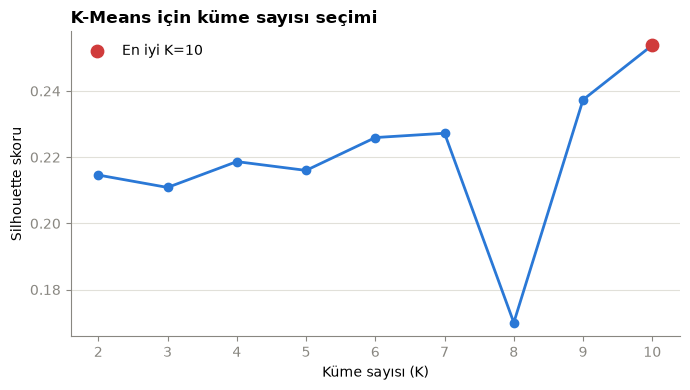

Seçilen K: 10 (silhouette skoru: 0.254)


In [4]:
COLOR_MAIN = '#2a78d6'
COLOR_MUTED = '#898781'
COLOR_TEXT = '#0b0b0b'

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), silhouette_scores, marker='o', color=COLOR_MAIN, linewidth=2, markersize=6)

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
best_score = max(silhouette_scores)
ax.scatter([best_k], [best_score], color='#d03b3b', zorder=5, s=80, label=f'En iyi K={best_k}')

ax.set_xlabel('Küme sayısı (K)')
ax.set_ylabel('Silhouette skoru')
ax.set_title('K-Means için küme sayısı seçimi', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f'Seçilen K: {best_k} (silhouette skoru: {best_score:.3f})')

In [5]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
plugin_profile['cluster'] = final_kmeans.fit_predict(profile_scaled)

print(f'{best_k} kümeye göre eklenti dağılımı:')
print(plugin_profile['cluster'].value_counts().sort_index())

10 kümeye göre eklenti dağılımı:
cluster
0    1523
1      83
2     338
3     154
4      14
5       3
6       5
7      11
8     891
9      19
Name: count, dtype: int64


### Bulgu (K seçimi)

İki şeyi not etmek gerekiyor:

1. **Silhouette skorları genel olarak düşük** (0.17–0.25 arasında) — bu, eklentilerin veri toplama profillerine göre **net, birbirinden kesin çizgilerle ayrılmış** kümeler oluşturmadığını gösteriyor. Beklenen bir sonuç aslında: gerçek dünya verisi nadiren mükemmel kümelere ayrılır, çoğu eklenti muhtemelen birkaç kategoriyi karışık şekilde kullanıyor.
2. K arttıkça skor genel olarak yükseliyor ve en yüksek skor K=10'da çıkıyor, ama **küme büyüklükleri çok dengesiz**: iki büyük küme (1523 ve 891 eklenti) çoğunluğu kaplıyor, geri kalan 8 küme çok daha küçük (bazıları sadece 3-19 eklenti). Bu küçük kümeler gürültü olabilir, ama aynı zamanda **çok spesifik, tek bir kategoriye yoğunlaşmış eklenti grupları** da olabilir — bunu bir sonraki adımda küme profillerine bakarak anlayacağız.

Şimdilik K=10'u veriden gelen seçim olarak kabul edip devam ediyoruz; küçük kümelerin anlamlı mı yoksa gürültü mü olduğuna profil analiziyle karar vereceğiz.